# Scaled-dot product attention
สิ่งที่หวังให้เรียนรู้เเละสำคัญมากจาก notebook นี้คือเรื่องของ dimension เพราะ
1. dimension ผิดจะ matmul กันไม่ได้
2. ใช้ set parameter


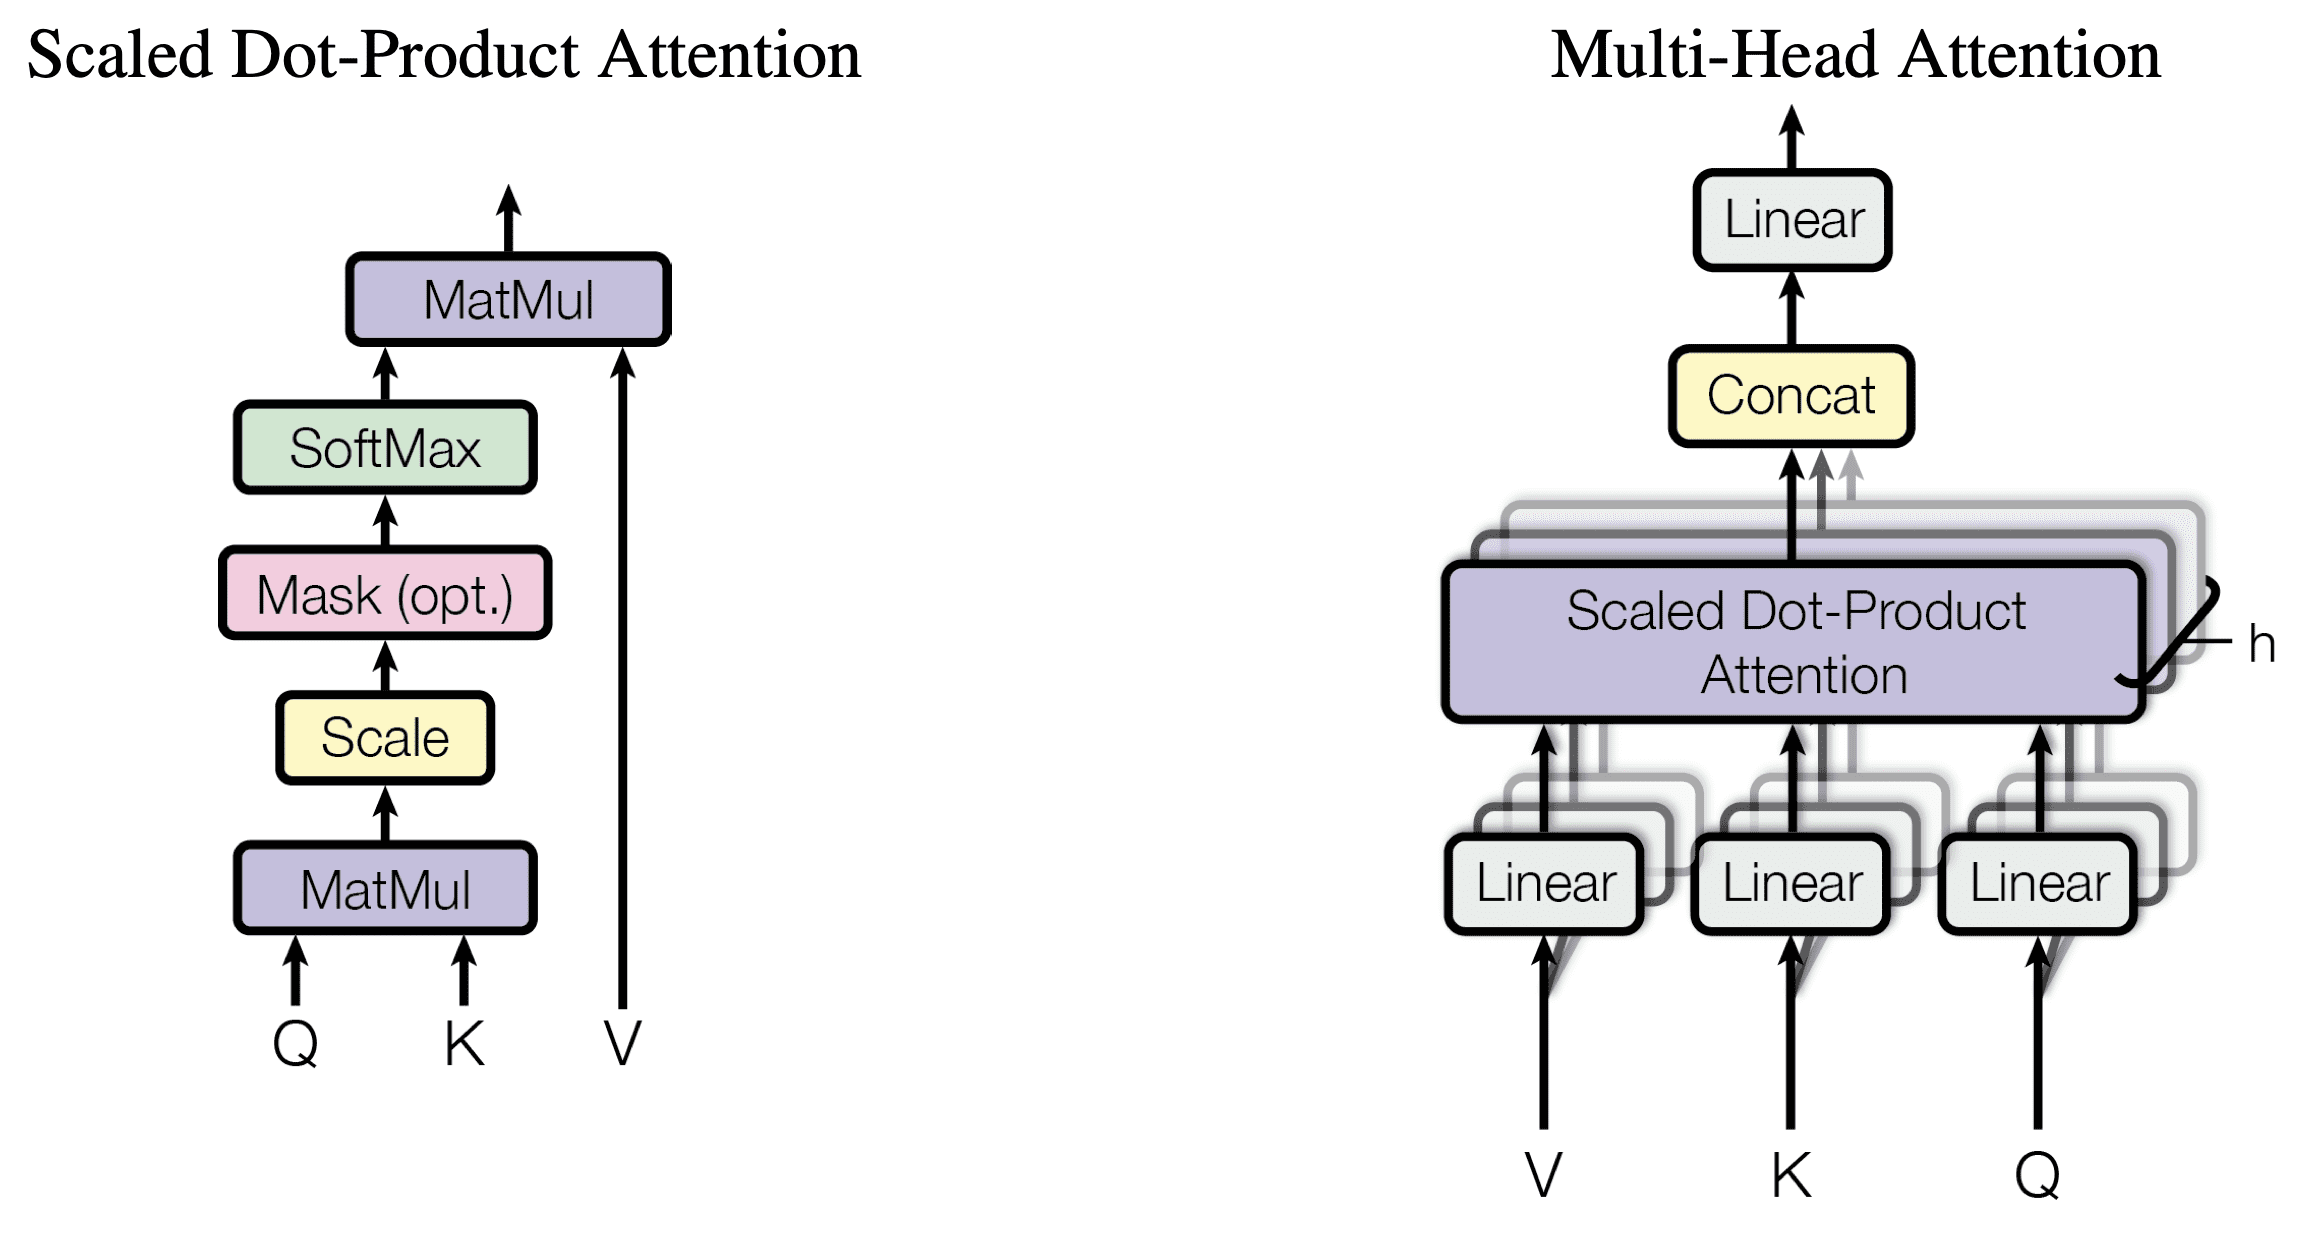

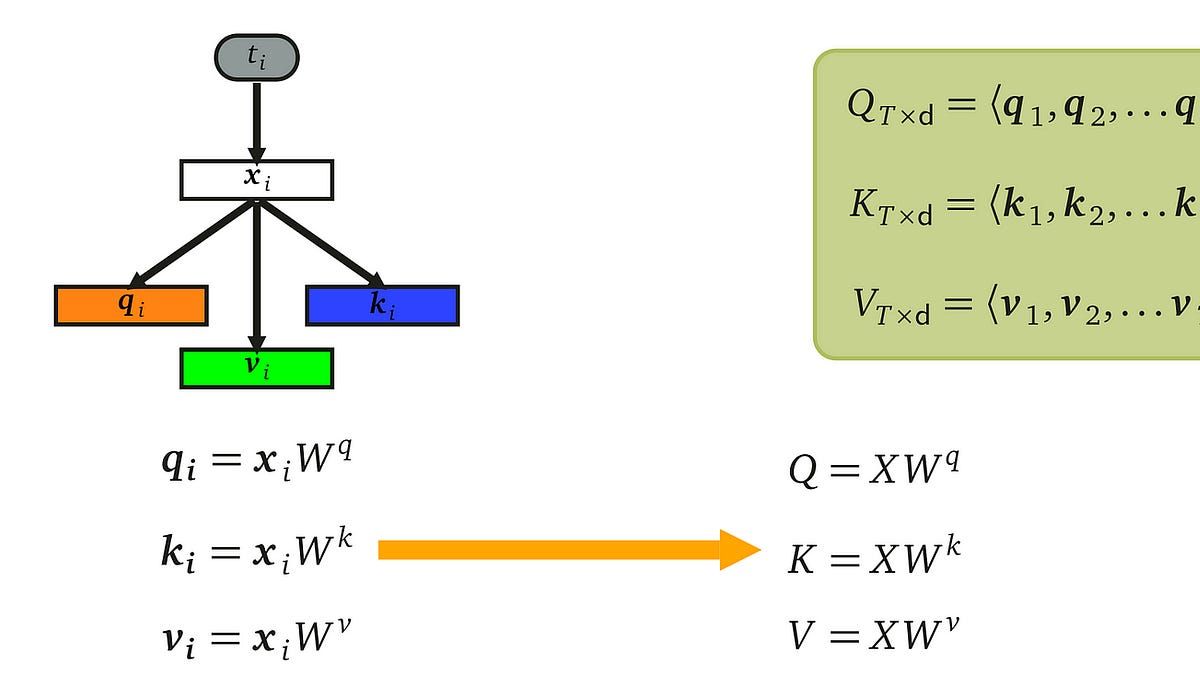

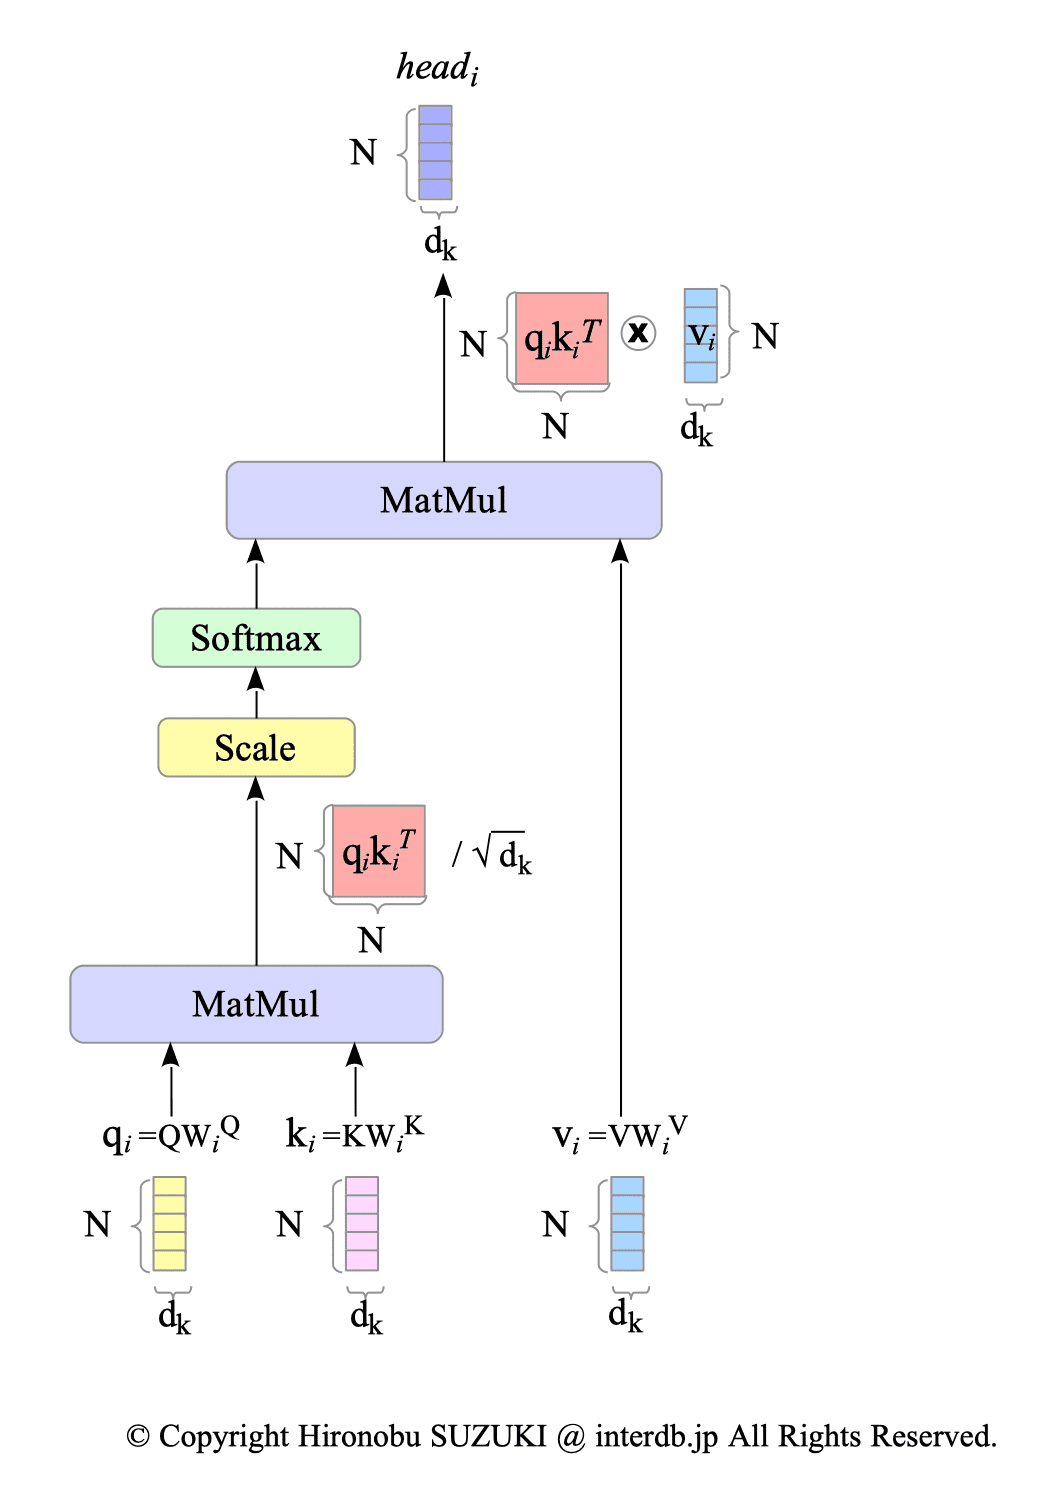

In [7]:
import torch
import torch.nn.functional as F

n, d, dk, h = 4, 8, 4, 2
x = torch.randn(n, d)
x

tensor([[ 1.1452, -0.0312,  0.5827,  2.7173, -0.2068,  2.0408, -1.0066,  0.0174],
        [-0.2224,  0.9393,  0.6970, -0.5204, -0.9487, -0.7412,  0.1538,  0.4835],
        [-1.5530, -0.2178,  0.5495, -0.4340, -0.2858, -0.7976, -0.0033,  0.3656],
        [-0.1615,  0.0479, -0.1356,  0.1561, -0.2961,  1.1240,  0.4588,  0.7236]])

ณ จุดนี้ x คือโดน tokenize เเละ embed มาเเล้ว

$x \in R^{nxd}$

In [6]:
WQ = torch.randn(d, dk)
WK = torch.randn(d, dk)
WV = torch.randn(d, dk)
WQ

tensor([[ 1.8805,  0.5071, -2.2181,  0.5242],
        [-2.1060, -0.3734, -0.9078, -0.4460],
        [ 0.3952, -1.9149, -1.6223, -0.1976],
        [ 0.3620,  0.4575, -1.6093,  0.1326],
        [ 0.3819, -1.5277, -1.4947,  1.2897],
        [ 0.0190,  0.7274, -0.6227,  0.2555],
        [ 0.0283, -0.7818,  0.2318, -0.0446],
        [ 1.8641,  1.6292,  0.4017, -0.8172]])

$W_{Q,K,V} \in R^{dxd_k}$
หลังจากนี้คือเราจะเอา $x$ มาคูณกับ $W_{Q,K,V}$
ผลลัพธ์ที่จะได้จะเป็น $R^{nxd_k}$

In [9]:
Q = x @ WQ
K = x @ WK
V = x @ WV
print(Q)
print(K)
print(V)

tensor([[ 3.3969,  3.3355, -9.0180,  1.1448],
        [-1.7801, -0.4585,  1.4569, -2.5573],
        [-1.8445, -1.5023,  4.5192, -1.7541],
        [ 0.8684,  2.3214,  0.4231, -0.7650]])
tensor([[-0.5406, -4.3139, -2.0618, -8.4307],
        [ 0.9893, -0.6205,  0.5213,  2.3000],
        [ 0.9137, -0.7274,  2.5249,  2.8726],
        [-0.4713, -0.9719,  2.0503, -2.8319]])
tensor([[-1.1713,  8.9508, -0.1391,  1.6359],
        [ 0.8205, -1.3552,  0.8145, -0.9522],
        [-0.9792, -2.0012, -0.2926, -0.2777],
        [-0.7176,  2.6261,  0.7492, -0.1077]])


ผลลัพธฺเป็น square matrix สังเกตว่าถ้าเคยเห็น attention weight map จะพบว่ามันควรเป็น square matrix ซึ่งสื่อความหมายว่าเเต่ละ token ต้องมีค่าเวทที่มัน attend ต่อกันหมด ซึ่ง make sense ที่จะเป็น $O(n^2)$ 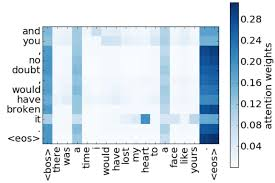

เเต่ความจริงเเล้ว statement นี้ผิดเพราะสังเกตว่าการที่มันเป็น square ได้เพราะว่าเซตให้ n กับ dk เป็นค่าเดียวกัน กรณีจะเป็น square matrix ได้เเปลว่าทุก token attend ต่อกันเองหรือก็คือวนกันเองในอ่างปิด นั่นก็คือ self-attention เเต่ถ้้าไป attend กับอ่างอื่นด้วยเราจะเรียกว่า cross-attention

In [11]:
scores = Q @ K.T / dk**0.5
scores

tensor([[ -3.6419,  -0.3886,  -9.4019, -13.2873],
        [ 10.7480,  -3.2993,  -2.4802,   5.7568],
        [  6.4744,  -1.2856,   2.8895,   8.2813],
        [ -2.4531,  -1.0601,  -1.0123,   0.1843]])

เราจะ mask มันหรือไม่นั้นขึ้นกับว่าเป็น encoder model หรือ decoder model ในกรณีนี้ขี้เกียจขอไม่ทำ

In [13]:
A = F.softmax(scores, dim=-1) #ใส่ softmax ให้ค่ามันไม่เพี้ยนเเละรวมกันได้ 1 ได้ถือเจ๊าๆกัน
A


tensor([[3.7205e-02, 9.6268e-01, 1.1723e-04, 2.4080e-06],
        [9.9325e-01, 7.8772e-07, 1.7870e-06, 6.7515e-03],
        [1.4046e-01, 5.9895e-05, 3.8961e-03, 8.5559e-01],
        [4.3052e-02, 1.7337e-01, 1.8186e-01, 6.0172e-01]])

ณ จุดนี้เราจะนำมาคูณกับตัว value

In [15]:
O = A @ V
O

tensor([[ 0.7462, -0.9718,  0.7789, -0.8559],
        [-1.1682,  8.9081, -0.1331,  1.6241],
        [-0.7822,  3.4962,  0.6204,  0.1365],
        [-0.5180,  1.3666,  0.5329, -0.2100]])

จริงๆยังไม่จบเพราะว่าถ้าสังเกตจะพบว่าจะมีการทำ residual connection อีกทีเพื่อ retain ข้อมูลซึ่ง O มีขนาดที่ไม่สามารถไปบวกกับ x ได้ เราจึงต้องสร้างเวกเตอร์ $W_O$ มาเพื่อจูนให้ O กลายเป็น $ Δx$ เพื่อจะไปทำ res ได้

เเล้วขนาดหละ? x มีขนาด nxd, O มีขนาด nxdk => $W_O$ ควรมีขนาด dk x d

In [16]:
WO = torch.randn(dk, d)
dx = O @ WO
dx

tensor([[ -0.2573,  -1.4577,   2.6292,  -1.9063,  -1.2738,  -2.0455,   0.3775,
          -1.7136],
        [  3.6409,  -1.1210, -18.9445,   4.2256,   6.0600,  14.6754,  -1.1662,
          -7.8522],
        [  1.2215,  -2.1155,  -8.5315,   0.7423,   1.9094,   5.8072,  -1.3283,
          -4.8802],
        [  0.3389,  -1.6481,  -3.8679,  -0.1665,   0.5407,   2.3100,  -0.9430,
          -2.7205]])

In [18]:
x = x + dx
x

tensor([[  0.6305,  -2.9466,   5.8411,  -1.0953,  -2.7545,  -2.0503,  -0.2517,
          -3.4098],
        [  7.0595,  -1.3026, -37.1921,   7.9308,  11.1713,  28.6096,  -2.1786,
         -15.2209],
        [  0.8901,  -4.4488, -16.5135,   1.0507,   3.5329,  10.8168,  -2.6600,
          -9.3949],
        [  0.5162,  -3.2482,  -7.8714,  -0.1768,   0.7854,   5.7441,  -1.4272,
          -4.7174]])